# Импорт необходимых библиотек

In [1]:
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Модель

In [2]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


class SupplierRiskModel:
    def __init__(self):
        self.model = None
        self.label_encoder = LabelEncoder()
        self.scaler = StandardScaler()
        self.power_transformer = PowerTransformer()
        self.feature_names = []
        self.best_model_name = ""

        # Определяем ожидаемые поля (без risk_score и risk_level для продакшена)
        self.expected_fields = [
            'has_losses', 'zero_revenue', 'no_reporting', 'has_profit',
            'company_age', 'recent_activity', 'tax_debt', 'mass_address',
            'unreliable_address', 'mass_manager', 'mass_shareholder',
            'has_bailiff_cases', 'bankruptcy_case', 'arbitration_cases',
            'government_owned', 'has_bank_license', 'has_insurance_license'
        ]

    def calculate_risk_score(self, data):
        """Вычисление risk_score на основе других признаков"""
        risk_factors = sum([
            data.get('has_losses', 0) * 1.5,
            data.get('zero_revenue', 0) * 1.5,
            data.get('no_reporting', 0) * 2.0,
            (1 - data.get('has_profit', 0)) * 1.0,
            data.get('tax_debt', 0) * 1.5,
            data.get('mass_address', 0) * 1.2,
            data.get('unreliable_address', 0) * 1.2,
            data.get('mass_manager', 0) * 1.0,
            data.get('mass_shareholder', 0) * 1.0,
            data.get('has_bailiff_cases', 0) * 1.3,
            data.get('bankruptcy_case', 0) * 2.5,
            min(3, data.get('arbitration_cases', 0)) * 0.8,
            (1 - data.get('recent_activity', 0)) * 0.7,
            max(0, (10 - data.get('company_age', 0)) / 10) * 0.5
        ])

        # Нормализуем score в диапазон 0-10 для согласованности
        normalized_score = min(10, max(0, risk_factors))
        return normalized_score

    def validate_input_data(self, input_data):
        """Валидация и подготовка входных данных"""
        if isinstance(input_data, dict):
            # Если это словарь с ID как ключами, извлекаем значения
            if all(isinstance(k, (int, str)) and not k in self.expected_fields for k in input_data.keys()):
                input_data = list(input_data.values())
            else:
                input_data = [input_data]

        validated_data = []
        for item in input_data:
            validated_item = {}

            # Проверяем наличие всех ожидаемых полей
            for field in self.expected_fields:
                if field in item:
                    validated_item[field] = item[field]
                else:
                    # Если поле отсутствует, используем значение по умолчанию
                    validated_item[field] = 0

            # Вычисляем risk_score на основе других полей
            validated_item['risk_score'] = self.calculate_risk_score(validated_item)

            validated_data.append(validated_item)

        return validated_data

    def create_high_quality_dataset(self, n_samples=5000):
        """Создание высококачественного набора данных с вычисляемым risk_score"""
        np.random.seed(42)

        data = []

        for i in range(n_samples):
            # Более сбалансированное распределение классов
            true_class = np.random.choice(
                ["МИНИМАЛЬНЫЙ_РИСК", "НИЗКИЙ_РИСК", "УМЕРЕННЫЙ_РИСК", "ПОВЫШЕННЫЙ_РИСК", "ВЫСОКИЙ_РИСК"],
                p=[0.22, 0.23, 0.22, 0.22, 0.11]
            )

            # Четкие правила генерации для каждого класса
            if true_class == "МИНИМАЛЬНЫЙ_РИСК":
                params = {
                    'has_losses': 0,
                    'zero_revenue': 0,
                    'no_reporting': 0,
                    'has_profit': 1,
                    'company_age': np.random.normal(18, 3),
                    'recent_activity': 1,
                    'tax_debt': 0,
                    'mass_address': 0,
                    'unreliable_address': 0,
                    'mass_manager': 0,
                    'mass_shareholder': 0,
                    'has_bailiff_cases': 0,
                    'bankruptcy_case': 0,
                    'arbitration_cases': np.random.poisson(0.05),
                    'government_owned': np.random.choice([0, 1], p=[0.7, 0.3]),
                    'has_bank_license': np.random.choice([0, 1], p=[0.6, 0.4]),
                    'has_insurance_license': np.random.choice([0, 1], p=[0.7, 0.3])
                }

            elif true_class == "НИЗКИЙ_РИСК":
                params = {
                    'has_losses': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'zero_revenue': np.random.choice([0, 1], p=[0.95, 0.05]),
                    'no_reporting': 0,
                    'has_profit': np.random.choice([0, 1], p=[0.2, 0.8]),
                    'company_age': np.random.normal(14, 4),
                    'recent_activity': 1,
                    'tax_debt': 0,
                    'mass_address': 0,
                    'unreliable_address': 0,
                    'mass_manager': np.random.choice([0, 1], p=[0.95, 0.05]),
                    'mass_shareholder': 0,
                    'has_bailiff_cases': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'bankruptcy_case': 0,
                    'arbitration_cases': np.random.poisson(0.2),
                    'government_owned': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'has_bank_license': np.random.choice([0, 1], p=[0.8, 0.2]),
                    'has_insurance_license': np.random.choice([0, 1], p=[0.85, 0.15])
                }

            elif true_class == "УМЕРЕННЫЙ_РИСК":
                params = {
                    'has_losses': np.random.choice([0, 1], p=[0.7, 0.3]),
                    'zero_revenue': np.random.choice([0, 1], p=[0.8, 0.2]),
                    'no_reporting': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'has_profit': np.random.choice([0, 1], p=[0.5, 0.5]),
                    'company_age': np.random.normal(10, 3),
                    'recent_activity': np.random.choice([0, 1], p=[0.2, 0.8]),
                    'tax_debt': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'mass_address': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'unreliable_address': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'mass_manager': np.random.choice([0, 1], p=[0.8, 0.2]),
                    'mass_shareholder': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'has_bailiff_cases': np.random.choice([0, 1], p=[0.7, 0.3]),
                    'bankruptcy_case': 0,
                    'arbitration_cases': np.random.poisson(0.8),
                    'government_owned': np.random.choice([0, 1], p=[0.95, 0.05]),
                    'has_bank_license': np.random.choice([0, 1], p=[0.95, 0.05]),
                    'has_insurance_license': np.random.choice([0, 1], p=[0.95, 0.05])
                }

            elif true_class == "ПОВЫШЕННЫЙ_РИСК":
                params = {
                    'has_losses': np.random.choice([0, 1], p=[0.3, 0.7]),
                    'zero_revenue': np.random.choice([0, 1], p=[0.6, 0.4]),
                    'no_reporting': np.random.choice([0, 1], p=[0.7, 0.3]),
                    'has_profit': np.random.choice([0, 1], p=[0.8, 0.2]),
                    'company_age': np.random.normal(6, 2),
                    'recent_activity': np.random.choice([0, 1], p=[0.4, 0.6]),
                    'tax_debt': np.random.choice([0, 1], p=[0.6, 0.4]),
                    'mass_address': np.random.choice([0, 1], p=[0.6, 0.4]),
                    'unreliable_address': np.random.choice([0, 1], p=[0.7, 0.3]),
                    'mass_manager': np.random.choice([0, 1], p=[0.6, 0.4]),
                    'mass_shareholder': np.random.choice([0, 1], p=[0.7, 0.3]),
                    'has_bailiff_cases': np.random.choice([0, 1], p=[0.4, 0.6]),
                    'bankruptcy_case': np.random.choice([0, 1], p=[0.9, 0.1]),
                    'arbitration_cases': np.random.poisson(1.8),
                    'government_owned': np.random.choice([0, 1], p=[0.98, 0.02]),
                    'has_bank_license': np.random.choice([0, 1], p=[0.98, 0.02]),
                    'has_insurance_license': np.random.choice([0, 1], p=[0.98, 0.02])
                }

            else:  # ВЫСОКИЙ_РИСК
                params = {
                    'has_losses': 1,
                    'zero_revenue': 1,
                    'no_reporting': 1,
                    'has_profit': 0,
                    'company_age': np.random.normal(2, 1),
                    'recent_activity': 0,
                    'tax_debt': 1,
                    'mass_address': 1,
                    'unreliable_address': 1,
                    'mass_manager': 1,
                    'mass_shareholder': 1,
                    'has_bailiff_cases': 1,
                    'bankruptcy_case': 1,
                    'arbitration_cases': np.random.poisson(4.5),
                    'government_owned': 0,
                    'has_bank_license': 0,
                    'has_insurance_license': 0
                }

            # Ограничиваем значения и добавляем немного шума
            params['company_age'] = max(0.5, params['company_age'])
            params['arbitration_cases'] = min(10, max(0, int(params['arbitration_cases'])))

            # ВЫЧИСЛЯЕМ risk_score вместо генерации
            params['risk_score'] = self.calculate_risk_score(params)
            params['risk_level'] = true_class  # Только для обучения

            data.append(params)

        return data

    def prepare_advanced_features(self, data):
        """Подготовка расширенных признаков"""
        features = []
        labels = []

        for item in data:
            # Вычисляем дополнительные признаки
            total_negative_factors = sum([
                item['has_losses'], item['zero_revenue'], item['no_reporting'],
                item['tax_debt'], item['mass_address'], item['unreliable_address'],
                item['has_bailiff_cases'], item['bankruptcy_case']
            ])

            stability_score = sum([
                item['has_profit'],
                item['recent_activity'],
                min(1, item['company_age'] / 10),
                1 if item['government_owned'] else 0
            ])

            # Базовые признаки
            feature_vector = [
                item['has_losses'],
                item['zero_revenue'],
                item['no_reporting'],
                item['has_profit'],
                item['company_age'],
                item['recent_activity'],
                item['tax_debt'],
                item['mass_address'],
                item['unreliable_address'],
                item['mass_manager'],
                item['mass_shareholder'],
                item['has_bailiff_cases'],
                item['bankruptcy_case'],
                item['arbitration_cases'],
                item['government_owned'],
                item['has_bank_license'],
                item['has_insurance_license'],
                item['risk_score'],  # Теперь вычисляется автоматически
                total_negative_factors,
                stability_score
            ]

            # Производные признаки
            feature_vector.extend([
                # Взаимодействия признаков
                item['has_losses'] * item['zero_revenue'],
                item['no_reporting'] * item['tax_debt'],
                item['mass_address'] * item['unreliable_address'],
                item['has_bailiff_cases'] * item['bankruptcy_case'],

                # Относительные показатели
                item['risk_score'] / max(1, item['company_age']),
                total_negative_factors / 8.0,  # нормализация
                item['arbitration_cases'] / max(1, item['company_age']),

                # Комбинированные индикаторы
                total_negative_factors - stability_score,
                (item['risk_score'] + total_negative_factors) / 2
            ])

            features.append(feature_vector)
            labels.append(item['risk_level'])  # Только для обучения

        self.feature_names = [
            'has_losses', 'zero_revenue', 'no_reporting', 'has_profit', 'company_age',
            'recent_activity', 'tax_debt', 'mass_address', 'unreliable_address',
            'mass_manager', 'mass_shareholder', 'has_bailiff_cases', 'bankruptcy_case',
            'arbitration_cases', 'government_owned', 'has_bank_license',
            'has_insurance_license', 'risk_score', 'total_negative_factors', 'stability_score',
            'losses_x_revenue', 'reporting_x_tax_debt', 'mass_x_unreliable', 'bailiff_x_bankruptcy',
            'risk_per_year', 'negative_factors_norm', 'cases_per_year',
            'risk_stability_balance', 'combined_risk_score'
        ]

        X = np.array(features)
        y = self.label_encoder.fit_transform(labels)

        return X, y

    def create_super_ensemble(self):
        """Создание супер-ансамбля моделей"""
        # Базовые модели
        base_models = [
            ('rf1', RandomForestClassifier(
                n_estimators=300, max_depth=25, min_samples_split=5,
                min_samples_leaf=2, max_features='sqrt', random_state=42,
                class_weight='balanced'
            )),
            ('rf2', BalancedRandomForestClassifier(
                n_estimators=200, max_depth=20, min_samples_split=8,
                min_samples_leaf=3, random_state=43
            )),
            ('xgb1', xgb.XGBClassifier(
                n_estimators=300, max_depth=10, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, random_state=42,
                eval_metric='mlogloss', scale_pos_weight=1
            )),
            ('gbm', GradientBoostingClassifier(
                n_estimators=300, max_depth=7, learning_rate=0.05,
                subsample=0.8, random_state=42
            ))
        ]

        # Мета-модель
        meta_model = LogisticRegression(
            multi_class='multinomial',
            random_state=42,
            max_iter=1000,
            C=0.5
        )

        # Стекинг ансамбль
        stacking_ensemble = StackingClassifier(
            estimators=base_models,
            final_estimator=meta_model,
            cv=5,
            passthrough=True,
            n_jobs=-1
        )

        return stacking_ensemble

    def train_high_accuracy_model(self, n_samples=5000):
        """Обучение высокоточной модели"""
        print("Создание высококачественного набора данных...")
        data = self.create_high_quality_dataset(n_samples)

        print("Подготовка расширенных признаков...")
        X, y = self.prepare_advanced_features(data)

        print(f"Размерность данных: {X.shape}")
        print(f"Классы: {self.label_encoder.classes_}")

        # Расширенная балансировка данных
        print("Балансировка данных...")
        smote = SMOTE(random_state=42, k_neighbors=3)
        X_balanced, y_balanced = smote.fit_resample(X, y)

        # Разделение данных
        X_train, X_test, y_train, y_test = train_test_split(
            X_balanced, y_balanced, test_size=0.15, random_state=42, stratify=y_balanced
        )

        # Продвинутая предобработка
        print("Предобработка данных...")
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_train_processed = self.power_transformer.fit_transform(X_train_scaled)

        X_test_scaled = self.scaler.transform(X_test)
        X_test_processed = self.power_transformer.transform(X_test_scaled)

        # Использование супер-ансамбля
        print("Использование супер-ансамбля...")
        self.model = self.create_super_ensemble()

        # Обучение модели
        print("Обучение модели...")
        self.model.fit(X_train_processed, y_train)

        # Предсказание и оценка
        y_pred = self.model.predict(X_test_processed)
        y_pred_proba = self.model.predict_proba(X_test_processed)

        # Расширенная оценка
        self.comprehensive_evaluation(y_test, y_pred, y_pred_proba, X_train_processed, y_train)

        return self.model

    def comprehensive_evaluation(self, y_true, y_pred, y_pred_proba, X_train, y_train):
        """Комплексная оценка модели"""
        print("\n" + "="*60)
        print("КОМПЛЕКСНАЯ ОЦЕНКА МОДЕЛИ")
        print("="*60)

        # Основные метрики
        accuracy = accuracy_score(y_true, y_pred)
        precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
        weighted_f1 = precision_recall_fscore_support(y_true, y_pred, average='weighted')[2]

        # Кросс-валидация
        cv_scores = cross_val_score(self.model, X_train, y_train, cv=5, scoring='accuracy')

        print(f"Точность: {accuracy:.4f}")
        print(f"Взвешенная F1-оценка: {weighted_f1:.4f}")
        print(f"Кросс-валидация (средняя): {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")

        print("\nМетрики по классам:")
        for i, class_name in enumerate(self.label_encoder.classes_):
            print(f"  {class_name}:")
            print(f"    Точность: {precision[i]:.4f}")
            print(f"    Полнота: {recall[i]:.4f}")
            print(f"    F1-оценка: {f1[i]:.4f}")

        print("\nДетальный отчет:")
        print(classification_report(y_true, y_pred, target_names=self.label_encoder.classes_))

        # Матрица ошибок
        self.plot_confusion_matrix(y_true, y_pred)

    def plot_confusion_matrix(self, y_true, y_pred):
        """Визуализация матрицы ошибок"""
        plt.figure(figsize=(10, 8))
        cm = confusion_matrix(y_true, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=self.label_encoder.classes_,
                   yticklabels=self.label_encoder.classes_,
                   cbar_kws={'label': 'Количество'})
        plt.title('Матрица ошибок', fontsize=16, fontweight='bold')
        plt.ylabel('Истинный класс', fontsize=12)
        plt.xlabel('Предсказанный класс', fontsize=12)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def predict_risk(self, input_data):
        """Предсказание риска для новых данных"""
        try:
            if self.model is None:
                raise ValueError("Модель не обучена.")

            # Валидация и подготовка входных данных
            validated_data = self.validate_input_data(input_data)

            if not validated_data:
                raise ValueError("Нет валидных данных для предсказания")

            features = []
            for item in validated_data:
                # Вычисляем дополнительные признаки
                total_negative_factors = sum([
                    item['has_losses'], item['zero_revenue'], item['no_reporting'],
                    item['tax_debt'], item['mass_address'], item['unreliable_address'],
                    item['has_bailiff_cases'], item['bankruptcy_case']
                ])

                stability_score = sum([
                    item['has_profit'],
                    item['recent_activity'],
                    min(1, item['company_age'] / 10),
                    1 if item['government_owned'] else 0
                ])

                # Базовые признаки
                feature_vector = [
                    item['has_losses'],
                    item['zero_revenue'],
                    item['no_reporting'],
                    item['has_profit'],
                    item['company_age'],
                    item['recent_activity'],
                    item['tax_debt'],
                    item['mass_address'],
                    item['unreliable_address'],
                    item['mass_manager'],
                    item['mass_shareholder'],
                    item['has_bailiff_cases'],
                    item['bankruptcy_case'],
                    item['arbitration_cases'],
                    item['government_owned'],
                    item['has_bank_license'],
                    item['has_insurance_license'],
                    item['risk_score'],  # Уже вычислен в validate_input_data
                    total_negative_factors,
                    stability_score
                ]

                # Производные признаки
                feature_vector.extend([
                    item['has_losses'] * item['zero_revenue'],
                    item['no_reporting'] * item['tax_debt'],
                    item['mass_address'] * item['unreliable_address'],
                    item['has_bailiff_cases'] * item['bankruptcy_case'],
                    item['risk_score'] / max(1, item['company_age']),
                    total_negative_factors / 8.0,
                    item['arbitration_cases'] / max(1, item['company_age']),
                    total_negative_factors - stability_score,
                    (item['risk_score'] + total_negative_factors) / 2
                ])

                features.append(feature_vector)

            X = np.array(features)
            X_scaled = self.scaler.transform(X)
            X_processed = self.power_transformer.transform(X_scaled)

            predictions = self.model.predict(X_processed)
            probabilities = self.model.predict_proba(X_processed)

            results = []
            for i, pred in enumerate(predictions):
                results.append({
                    'predicted_risk': self.label_encoder.inverse_transform([pred])[0],
                    'confidence': np.max(probabilities[i]),
                    'probabilities': {
                        class_name: prob for class_name, prob in
                        zip(self.label_encoder.classes_, probabilities[i])
                    },
                    'risk_factors': self.analyze_risk_factors(validated_data[i]),
                    'risk_breakdown': self.get_risk_breakdown(validated_data[i]),
                    'calculated_risk_score': validated_data[i]['risk_score']  # Показываем вычисленный score
                })

            return results

        except Exception as e:
            # Логируем ошибку и возвращаем понятное сообщение
            error_msg = f"Ошибка при предсказании: {str(e)}"
            print(f"ERROR: {error_msg}")
            return [{'error': error_msg}]

    def analyze_risk_factors(self, data):
        """Анализ факторов риска"""
        risk_factors = []

        if data.get('has_losses', 0):
            risk_factors.append("НаличиеУбытков")
        if data.get('zero_revenue', 0):
            risk_factors.append("НулеваяВыручка")
        if data.get('no_reporting', 0):
            risk_factors.append("ОтсутствиеОтчетности")
        if not data.get('has_profit', 0):
            risk_factors.append("ОтсутствиеПрибыли")
        if data.get('tax_debt', 0):
            risk_factors.append("НалоговаяЗадолженность")
        if data.get('mass_address', 0):
            risk_factors.append("МассовыйАдрес")
        if data.get('has_bailiff_cases', 0):
            risk_factors.append("НаличиеИсполнительныхПроизводств")
        if data.get('bankruptcy_case', 0):
            risk_factors.append("ДелоОБанкротстве")
        if data.get('arbitration_cases', 0) > 2:
            risk_factors.append(f"МножествоАрбитражныхДел-({data.get('arbitration_cases', 0)})")

        return risk_factors

    def get_risk_breakdown(self, data):
        """Детальный анализ рисков"""
        breakdown = {
            'financial_risk': sum([data.get('has_losses', 0), data.get('zero_revenue', 0), not data.get('has_profit', 0)]),
            'legal_risk': sum([data.get('has_bailiff_cases', 0), data.get('bankruptcy_case', 0), min(1, data.get('arbitration_cases', 0))]),
            'reputation_risk': sum([data.get('mass_address', 0), data.get('unreliable_address', 0), data.get('mass_manager', 0)]),
            'operational_risk': sum([data.get('no_reporting', 0), data.get('tax_debt', 0), not data.get('recent_activity', 0)]),
            'stability_score': sum([data.get('has_profit', 0), data.get('recent_activity', 0), min(1, data.get('company_age', 0)/5)])
        }
        return breakdown

    def save_model(self, filepath):
        """Сохранение модели"""
        model_data = {
            'model': self.model,
            'label_encoder': self.label_encoder,
            'scaler': self.scaler,
            'power_transformer': self.power_transformer,
            'feature_names': self.feature_names,
            'best_model_name': self.best_model_name,
            'expected_fields': self.expected_fields
        }
        joblib.dump(model_data, filepath)
        print(f"Модель сохранена в {filepath}")

    def load_model(self, filepath):
        """Загрузка модели"""
        model_data = joblib.load(filepath)
        self.model = model_data['model']
        self.label_encoder = model_data['label_encoder']
        self.scaler = model_data['scaler']
        self.power_transformer = model_data['power_transformer']
        self.feature_names = model_data['feature_names']
        self.best_model_name = model_data['best_model_name']
        self.expected_fields = model_data.get('expected_fields', self.expected_fields)
        print(f"Модель загружена из {filepath}")

# Обучение и сохранение модели

Создание высококачественного набора данных...
Подготовка расширенных признаков...
Размерность данных: (1500, 29)
Классы: ['ВЫСОКИЙ_РИСК' 'МИНИМАЛЬНЫЙ_РИСК' 'НИЗКИЙ_РИСК' 'ПОВЫШЕННЫЙ_РИСК'
 'УМЕРЕННЫЙ_РИСК']
Балансировка данных...
Предобработка данных...
Использование супер-ансамбля...
Обучение модели...

КОМПЛЕКСНАЯ ОЦЕНКА МОДЕЛИ
Точность: 0.8577
Взвешенная F1-оценка: 0.8566
Кросс-валидация (средняя): 0.8462 (+/- 0.0199)

Метрики по классам:
  ВЫСОКИЙ_РИСК:
    Точность: 1.0000
    Полнота: 1.0000
    F1-оценка: 1.0000
  МИНИМАЛЬНЫЙ_РИСК:
    Точность: 0.8033
    Полнота: 0.9245
    F1-оценка: 0.8596
  НИЗКИЙ_РИСК:
    Точность: 0.8222
    Полнота: 0.6981
    F1-оценка: 0.7551
  ПОВЫШЕННЫЙ_РИСК:
    Точность: 0.9020
    Полнота: 0.8519
    F1-оценка: 0.8762
  УМЕРЕННЫЙ_РИСК:
    Точность: 0.7679
    Полнота: 0.8113
    F1-оценка: 0.7890

Детальный отчет:
                  precision    recall  f1-score   support

    ВЫСОКИЙ_РИСК       1.00      1.00      1.00        54
МИНИМАЛЬНЫЙ_РИСК

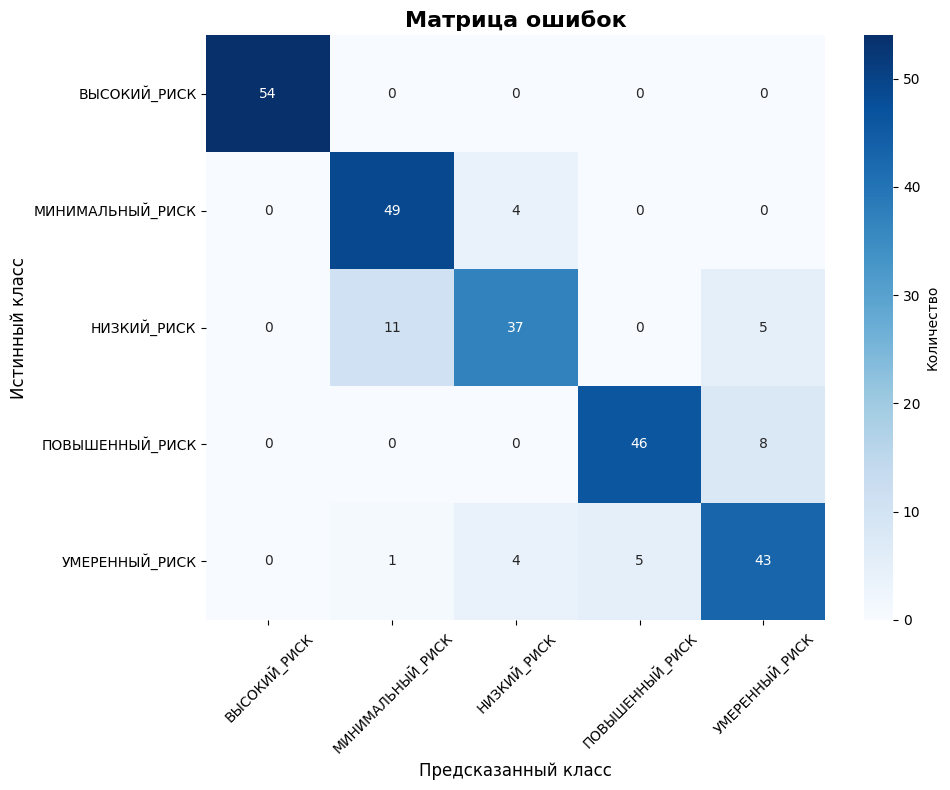

Модель сохранена в high_accuracy_supplier_risk_model.pkl

ТЕСТИРОВАНИЕ НА РЕАЛЬНЫХ ДАННЫХ (без risk_score)
Предсказанный риск: УМЕРЕННЫЙ_РИСК
Уверенность: 0.7829
Вычисленный risk_score: 2.55
Факторы риска: НаличиеУбытков, ОтсутствиеПрибыли
Распределение вероятностей:
  ВЫСОКИЙ_РИСК: 0.0001
  МИНИМАЛЬНЫЙ_РИСК: 0.0000
  НИЗКИЙ_РИСК: 0.1723
  ПОВЫШЕННЫЙ_РИСК: 0.0447
  УМЕРЕННЫЙ_РИСК: 0.7829


In [3]:
 # Инициализация и обучение модели
model = SupplierRiskModel()
trained_model = model.train_high_accuracy_model(n_samples=1500)

# Сохранение модели
model.save_model('high_accuracy_supplier_risk_model.pkl')

# Тестирование на реальных данных (без risk_score)
test_data = {
    7839071862: {
        'has_losses': 1,
        'company_age': 9.0,
        'recent_activity': 1,
        'tax_debt': 0,
        'mass_address': 0,
        'unreliable_address': 0,
        'has_bailiff_cases': 0,
        'bankruptcy_case': 0,
        'zero_revenue': 0,
        'no_reporting': 0,
        'has_profit': 0,
        'mass_manager': 0,
        'mass_shareholder': 0,
        'arbitration_cases': 0,
        'government_owned': 0,
        'has_bank_license': 0,
        'has_insurance_license': 0
    }
}

print("\n" + "="*50)
print("ТЕСТИРОВАНИЕ НА РЕАЛЬНЫХ ДАННЫХ (без risk_score)")
print("="*50)

predictions = model.predict_risk(test_data)

if 'error' in predictions[0]:
    print(f"Ошибка: {predictions[0]['error']}")
else:
    prediction = predictions[0]
    print(f"Предсказанный риск: {prediction['predicted_risk']}")
    print(f"Уверенность: {prediction['confidence']:.4f}")
    print(f"Вычисленный risk_score: {prediction['calculated_risk_score']:.2f}")
    print(f"Факторы риска: {', '.join(prediction['risk_factors']) if prediction['risk_factors'] else 'Нет значимых факторов'}")
    print("Распределение вероятностей:")
    for risk_class, prob in prediction['probabilities'].items():
        print(f"  {risk_class}: {prob:.4f}")